In [3]:
#imports
from google.colab import drive
import os
import numpy as np
import random
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import shutil
import zipfile


In [4]:
#montar el drive
drive.mount('/content/drive')

DRIVE_TFM   = '/content/drive/MyDrive/TFM_ID_Cards'
DIR_IDCARDS = '/content/data_tfm/ID_CARDS'
DIR_SYNPASS = '/content/data_tfm/SYN_PASS'

os.makedirs(DIR_IDCARDS, exist_ok=True)
os.makedirs(DIR_SYNPASS, exist_ok=True)

Mounted at /content/drive


In [5]:
#Extraer ID CARDS, extraer SYN PASS
datasets = [
    ('ID CARDS', f'{DRIVE_TFM}/Dataset ID CARDS Final.zip', DIR_IDCARDS),
    ('SYN PASS', f'{DRIVE_TFM}/SYN ID PASS Final.zip',     DIR_SYNPASS),
]

for nombre, zip_path, destino in datasets:
    with zipfile.ZipFile(zip_path, 'r') as z:
        z.extractall(destino)

In [8]:
extensiones_imagen = {'.jpg', '.jpeg', '.png', '.bmp', '.tiff', '.webp'}

def explorar(nombre, ruta_base):
    conteo = {}
    for ruta, dirs, archivos in os.walk(ruta_base):
        dirs[:] = [d for d in dirs if d != '__MACOSX']
        imagenes = [a for a in archivos if os.path.splitext(a)[1].lower() in extensiones_imagen]
        if imagenes:
            clave = os.path.relpath(ruta, ruta_base).replace(os.sep, '/')
            conteo[clave] = len(imagenes)

    for carpeta, n in sorted(conteo.items()):
        print(f'  {carpeta}: {n} imagenes')
    print(f'\nTotal {nombre}: {sum(conteo.values())} imagenes')
    return conteo

conteo_idcards = explorar('ID CARDS', f'{DIR_IDCARDS}/Dataset ID CARDS Final')
print()
conteo_synpass = explorar('SYN PASS', f'{DIR_SYNPASS}/SYN ID PASS Final')

  NTS-2026/cyclegan/print: 3391 imagenes
  NTS-2026/cyclegan/screen: 2033 imagenes
  bonafide-ijcb2025PAD-IDcard/bonafide: 3000 imagenes
  composite-ijcb2025PAD-IDcard/composite: 3000 imagenes
  print-ijcb2025PAD-IDcard/print: 3000 imagenes
  screen-ijcb2025PAD-IDcard/screen: 3000 imagenes

Total ID CARDS: 17424 imagenes

  poland/bonafide: 1015 imagenes
  poland/printed: 1016 imagenes
  poland/screen: 1015 imagenes
  portugal/bonafide: 1015 imagenes
  portugal/printed: 1014 imagenes
  portugal/screen: 1014 imagenes
  spain/bonafide: 1015 imagenes
  spain/printed: 1019 imagenes
  spain/screen: 1018 imagenes

Total SYN PASS: 9141 imagenes


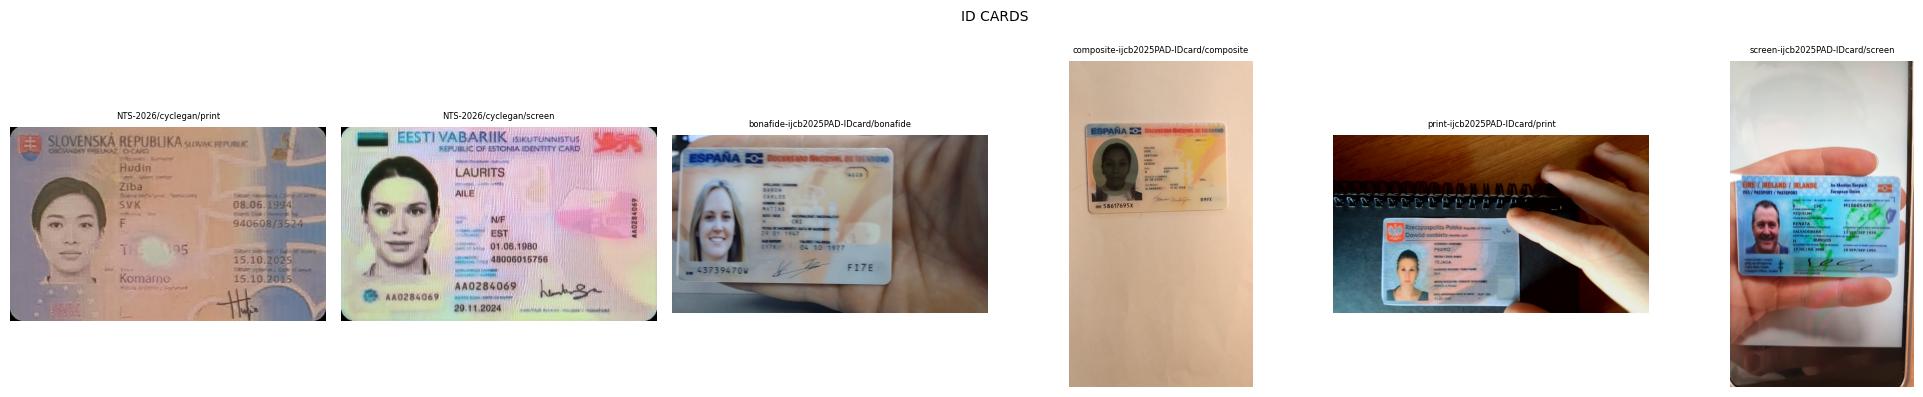

In [9]:
def mostrar_muestras(nombre, conteo, ruta_base):
    fig, axes = plt.subplots(1, len(conteo), figsize=(20, 4))
    fig.suptitle(nombre, fontsize=10)
    for ax, carpeta in zip(axes, sorted(conteo)):
        ruta = os.path.join(ruta_base, carpeta.replace('/', os.sep))
        fotos = [f for f in os.listdir(ruta) if os.path.splitext(f)[1].lower() in extensiones_imagen]
        ax.imshow(mpimg.imread(os.path.join(ruta, random.choice(fotos))))
        ax.set_title(carpeta, fontsize=6)
        ax.axis('off')
    plt.tight_layout()
    plt.show()

mostrar_muestras('ID CARDS', conteo_idcards, f'{DIR_IDCARDS}/Dataset ID CARDS Final')

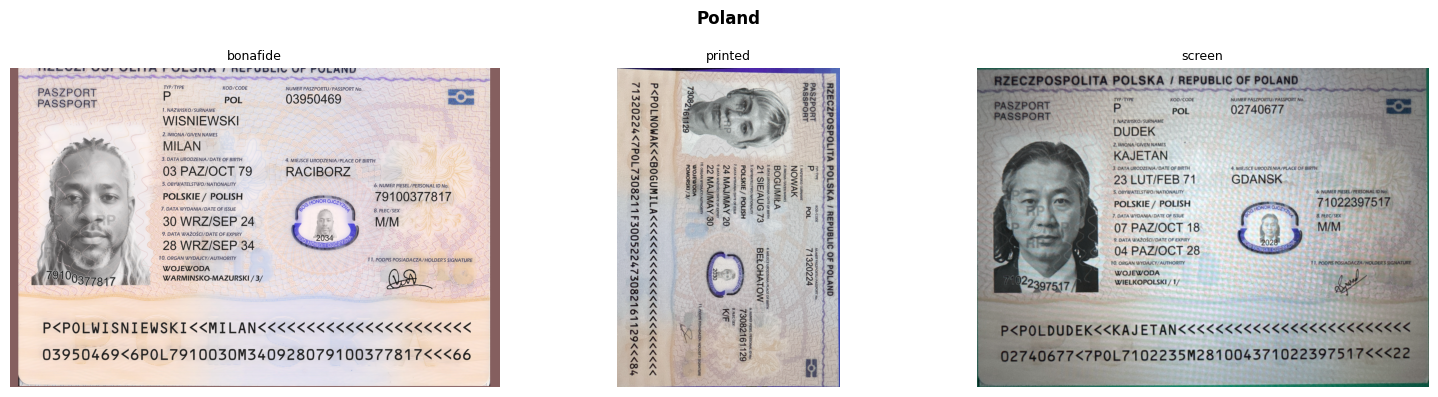

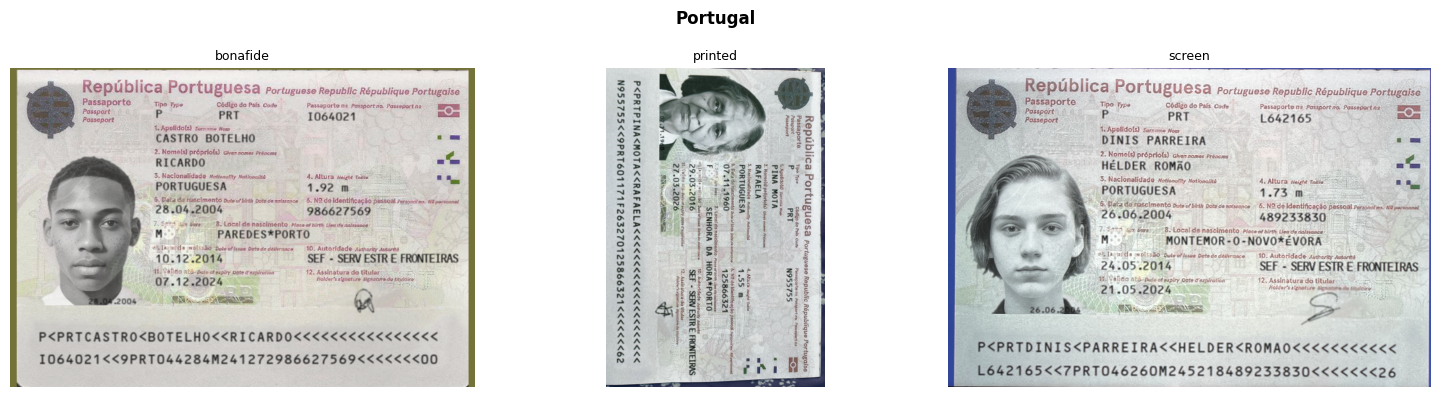

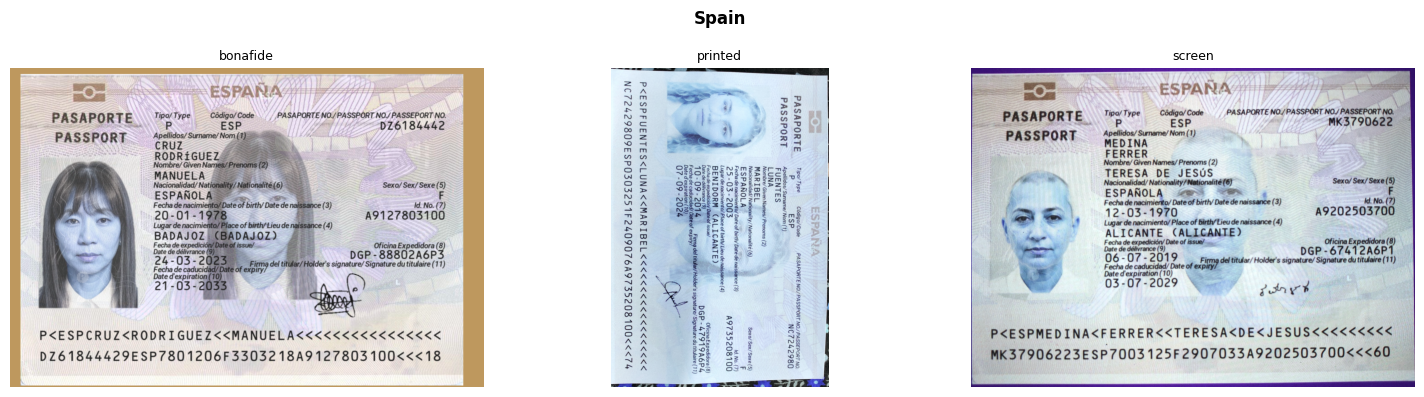

In [13]:
paises = sorted(set(c.split('/')[0] for c in conteo_synpass))
tipos  = sorted(set(c.split('/')[1] for c in conteo_synpass))

for pais in paises:
    fig, axes = plt.subplots(1, len(tipos), figsize=(15, 4))
    fig.suptitle(pais.capitalize(), fontsize=12, fontweight='bold')
    for ax, tipo in zip(axes, tipos):
        ruta = os.path.join(f'{DIR_SYNPASS}/SYN ID PASS Final', pais, tipo)
        fotos = [f for f in os.listdir(ruta) if os.path.splitext(f)[1].lower() in extensiones_imagen]
        ax.imshow(mpimg.imread(os.path.join(ruta, random.choice(fotos))))
        ax.set_title(tipo, fontsize=9)
        ax.axis('off')
    plt.tight_layout()
    plt.show()